<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Car_Sales_Info_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Sales Dataset ( Treans and Prices )

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d minahilfatima12328/car-sales-info

# Unziping the downloaded file
!unzip car-sales-info.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/minahilfatima12328/car-sales-info
License(s): CC0-1.0
  0% 0.00/489k [00:00<?, ?B/s]
100% 489k/489k [00:00<00:00, 641MB/s]
Archive:  car-sales-info.zip
  inflating: car_sales_data.csv      


In [5]:
df = pd.read_csv('car_sales_data.csv')
df.head(11)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


In [6]:
df.tail(11)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
49989,Ford,Fiesta,1.2,Diesel,2000,79154,4412
49990,Toyota,RAV4,2.4,Hybrid,2001,39250,17434
49991,Toyota,RAV4,2.0,Hybrid,2004,105792,12427
49992,VW,Polo,1.4,Petrol,2012,48057,12703
49993,Ford,Mondeo,1.8,Petrol,2003,120969,6654
49994,Toyota,RAV4,1.8,Hybrid,2002,101634,10639
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [7]:
df.shape

(50000, 7)

In [8]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='object')

In [9]:
df.dtypes

,0
Manufacturer,object
Model,object
Engine size,float64
Fuel type,object
Year of manufacture,int64
Mileage,int64
Price,int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [11]:
df.describe(include = 'all')

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
count,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000
unique,5,15,NaN,3,NaN,NaN,NaN
top,Ford,Mondeo,NaN,Petrol,NaN,NaN,NaN
freq,14959,5058,NaN,25488,NaN,NaN,NaN
mean,NaN,NaN,1.773058,NaN,2004.209440,112497.320700,13828.903160
std,NaN,NaN,0.734108,NaN,9.645965,71632.515602,16416.681336
min,NaN,NaN,1.000000,NaN,1984.000000,630.000000,76.000000
25%,NaN,NaN,1.400000,NaN,1996.000000,54352.250000,3060.750000
50%,NaN,NaN,1.600000,NaN,2004.000000,100987.500000,7971.500000
75%,NaN,NaN,2.000000,NaN,2012.000000,158601.000000,19026.500000


In [13]:
df.isnull().sum()

,0
Manufacturer,0
Model,0
Engine size,0
Fuel type,0
Year of manufacture,0
Mileage,0
Price,0


In [14]:
df.duplicated().sum()

np.int64(12)

# Handling Outliers

In [15]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Mileage'] >= lower_bound) & (df['Mileage'] <= upper_bound)].copy()

print('Before removing outliers:', len(df))
print('After removing outleirs:', len(df_outliers))

Before removing outliers: 50000
After removing outleirs: 49615


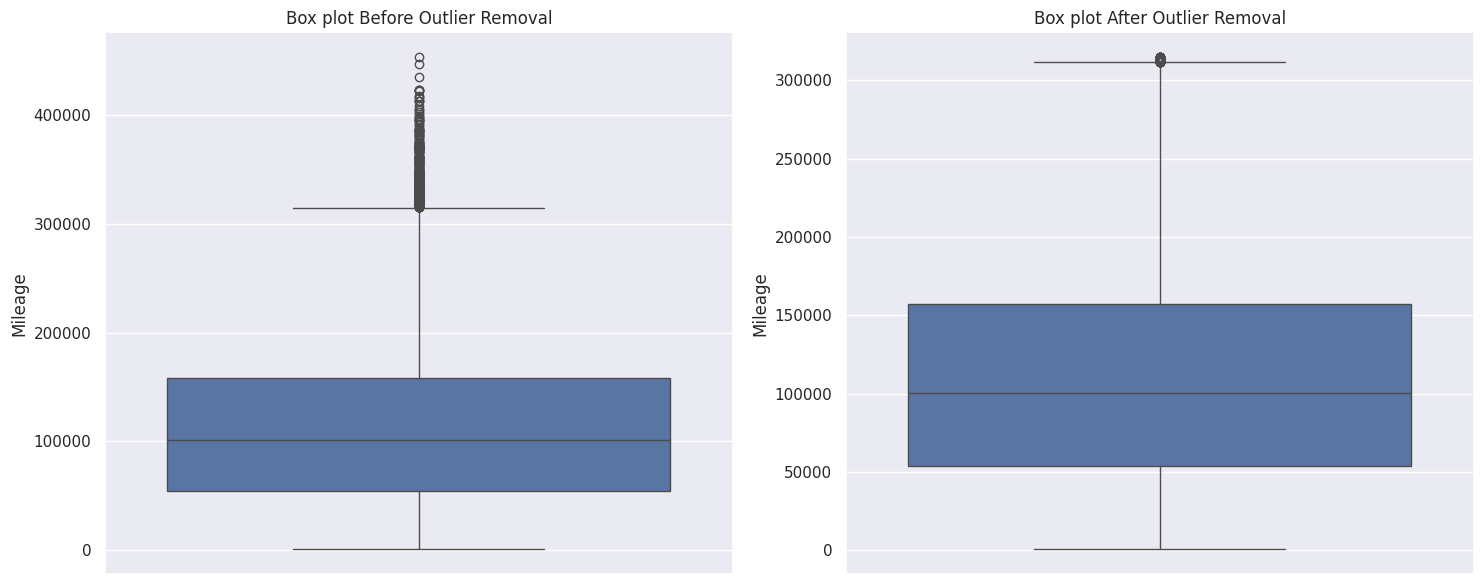

In [16]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='Mileage', ax=axes[0])
axes[0].set_title('Box plot Before Outlier Removal')
axes[0].set_ylabel('Mileage')

sns.boxplot(data=df_outliers, y='Mileage', ax=axes[1])
axes[1].set_title('Box plot After Outlier Removal')
axes[1].set_ylabel('Mileage')

plt.tight_layout()
plt.show()

# Univariate Analysis

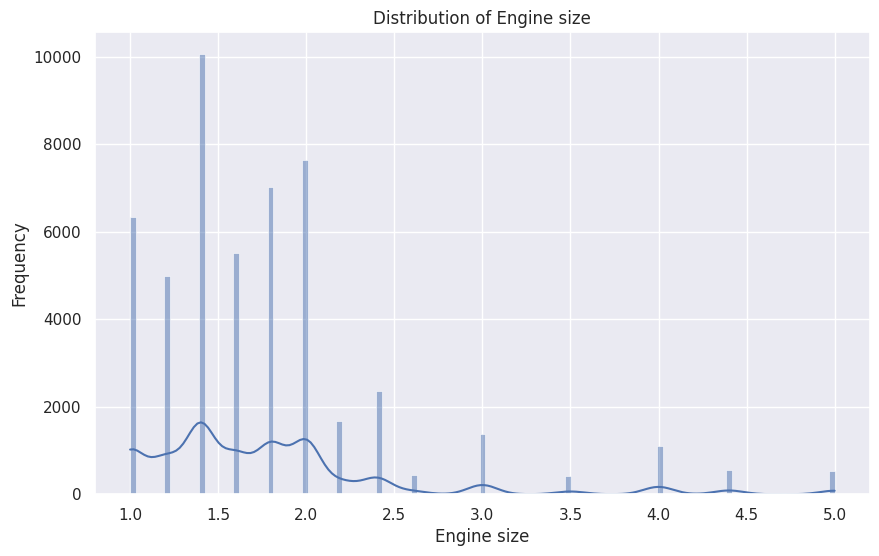

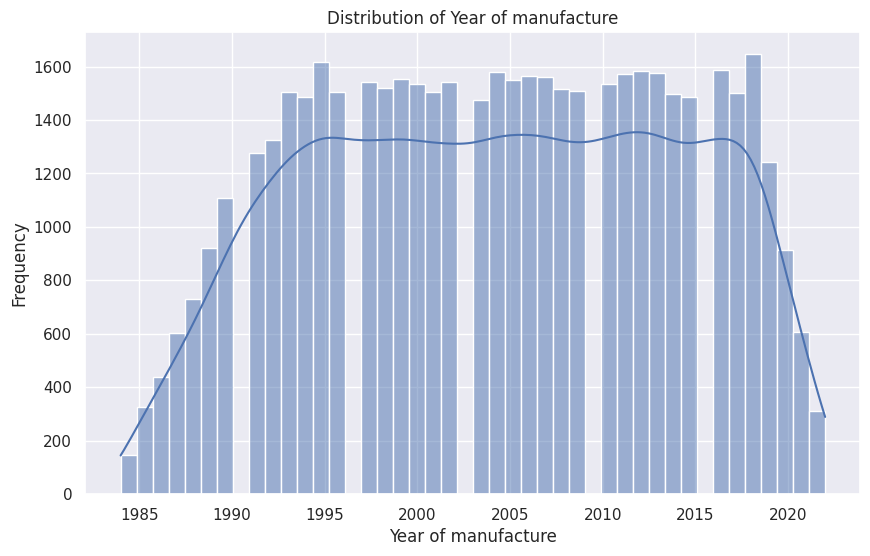

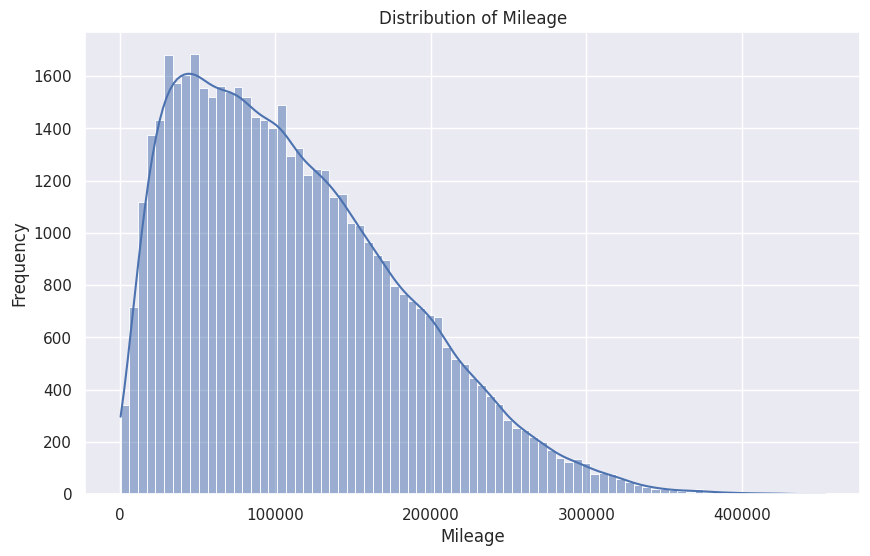

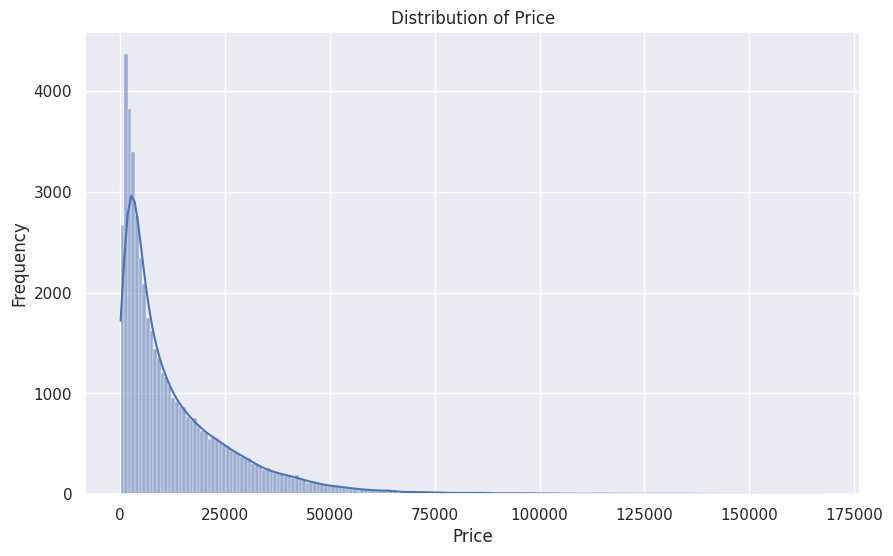

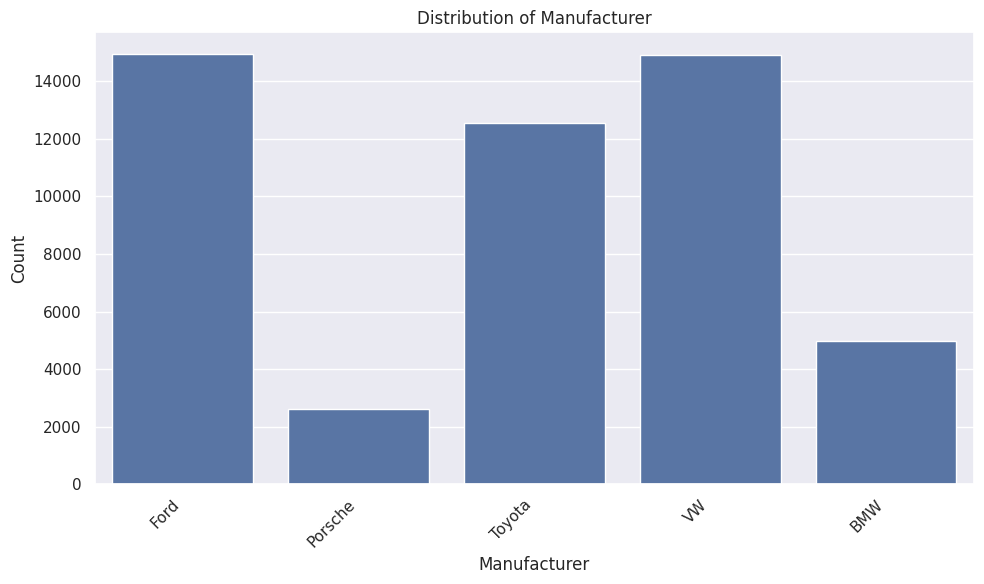

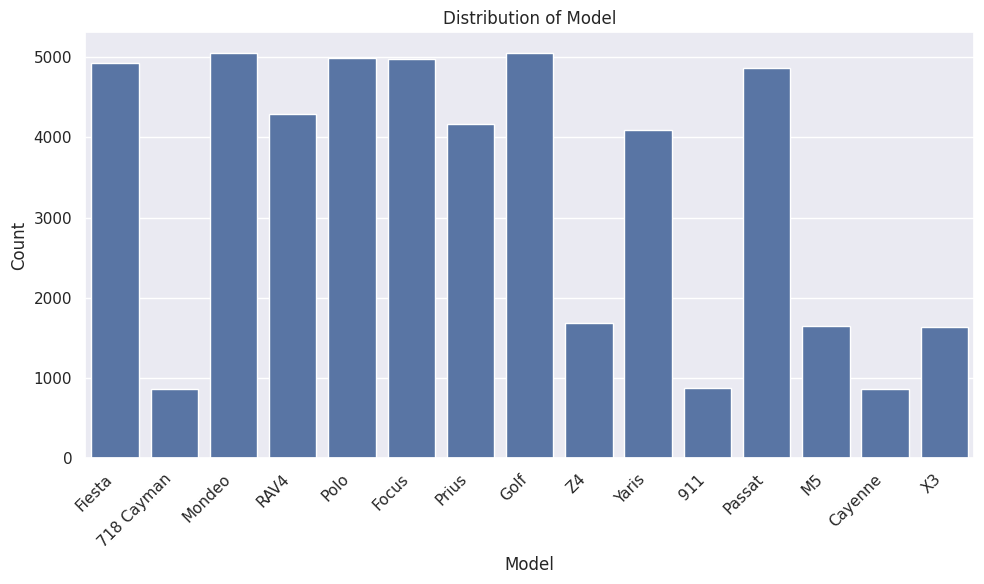

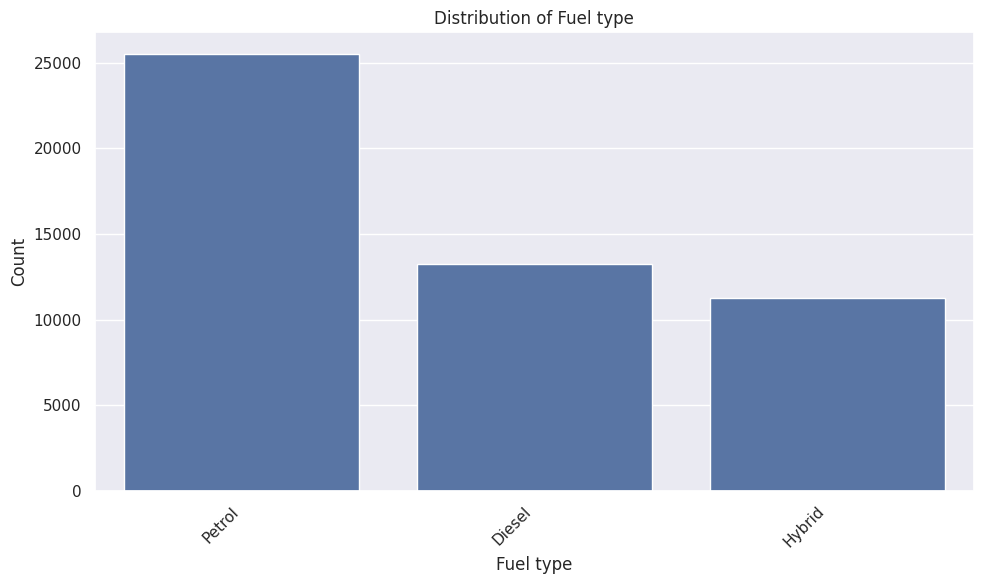

Value counts for Manufacturer:
Manufacturer
Ford       14959
VW         14913
Toyota     12554
BMW         4965
Porsche     2609
Name: count, dtype: int64

Value counts for Model:
Model
Mondeo        5058
Golf          5050
Polo          4992
Focus         4976
Fiesta        4925
Passat        4871
RAV4          4292
Prius         4171
Yaris         4091
Z4            1688
M5            1645
X3            1632
911            872
Cayenne        870
718 Cayman     867
Name: count, dtype: int64

Value counts for Fuel type:
Fuel type
Petrol    25488
Diesel    13268
Hybrid    11244
Name: count, dtype: int64



In [18]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

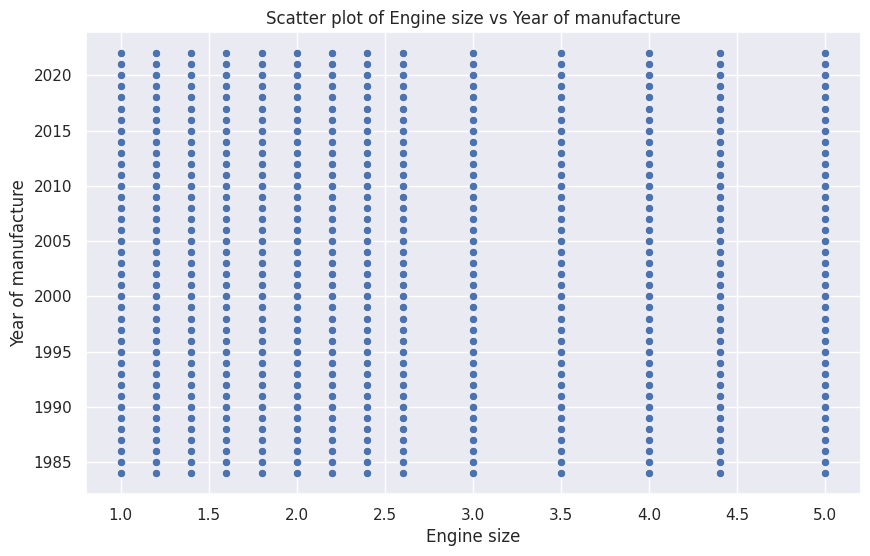

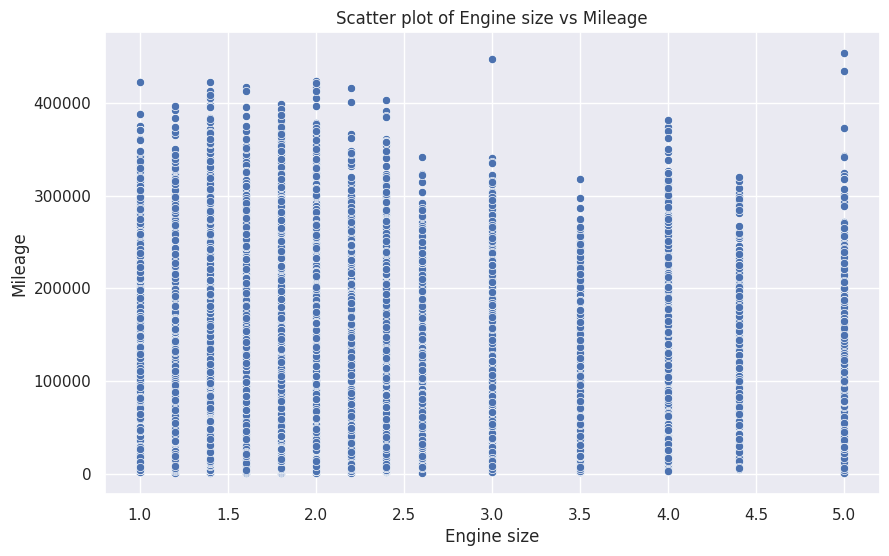

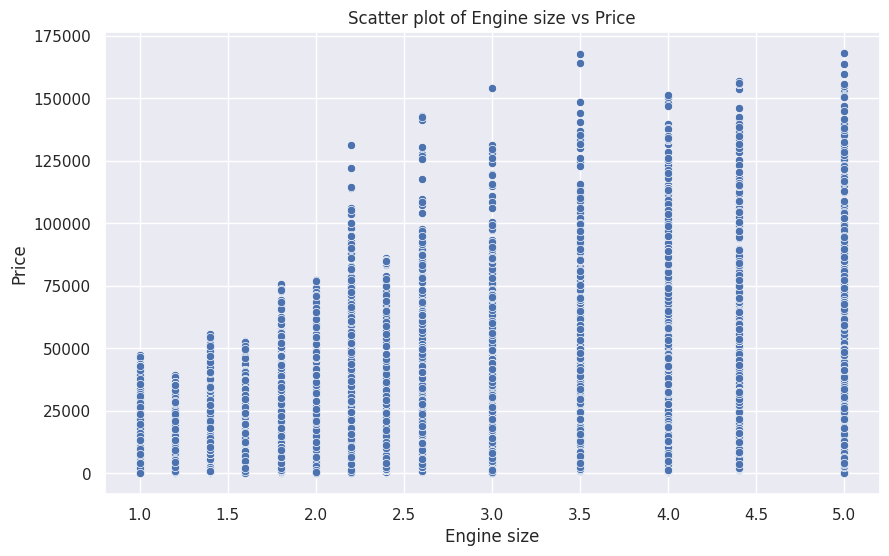

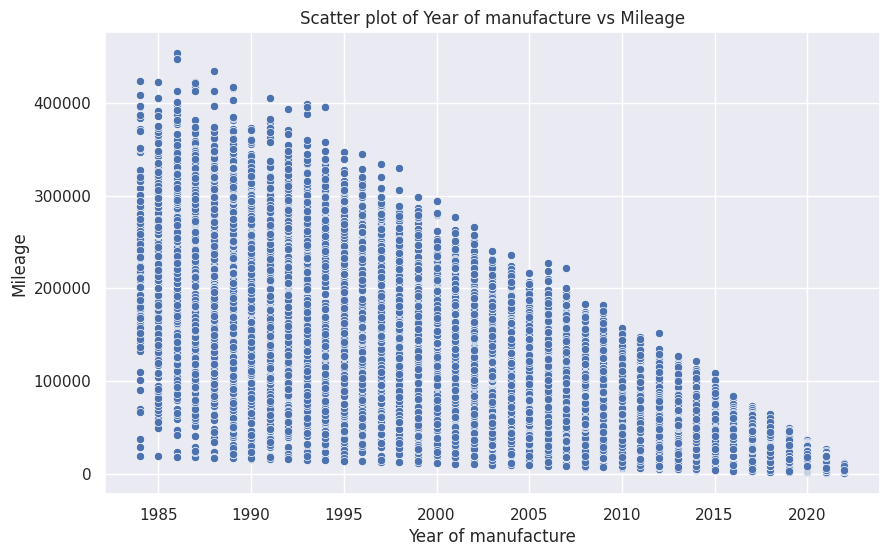

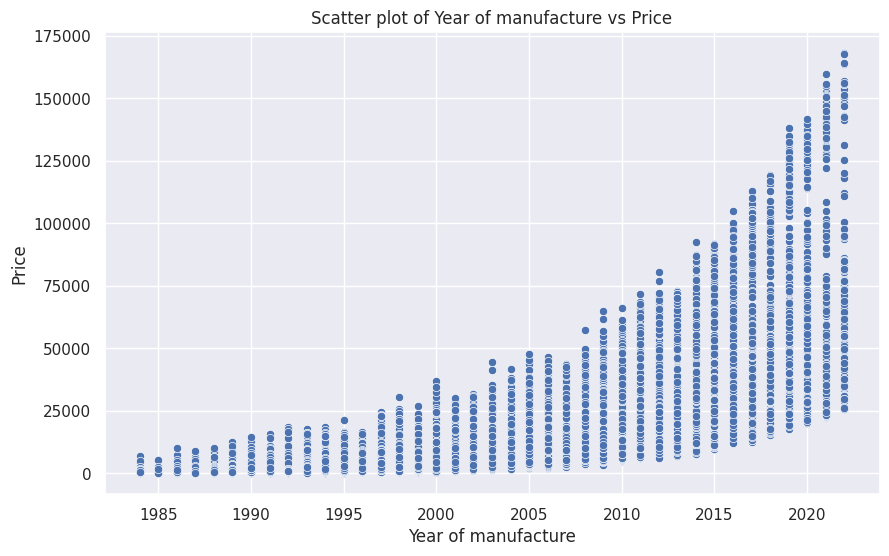

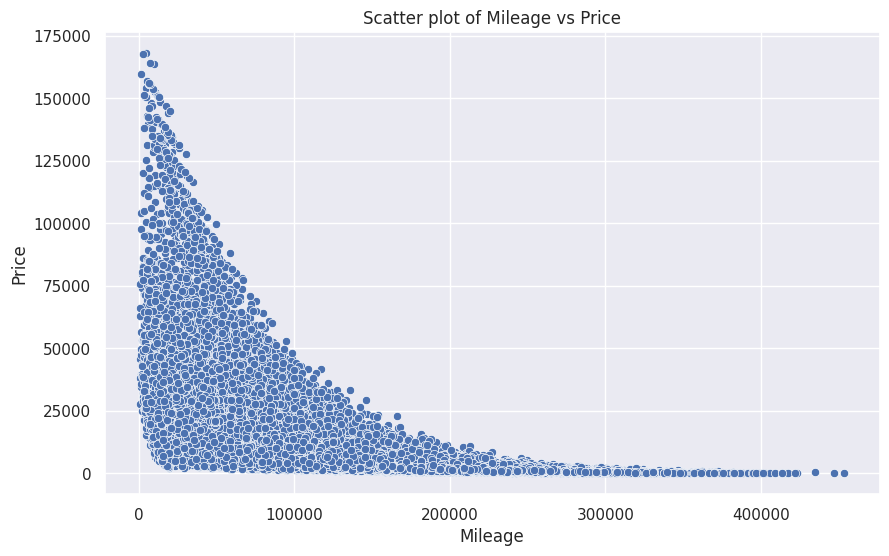

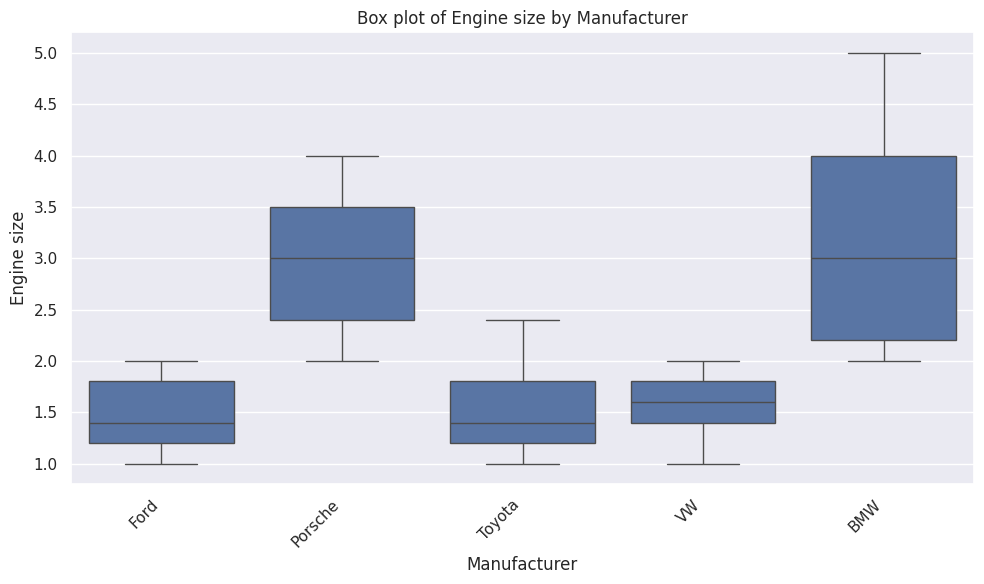

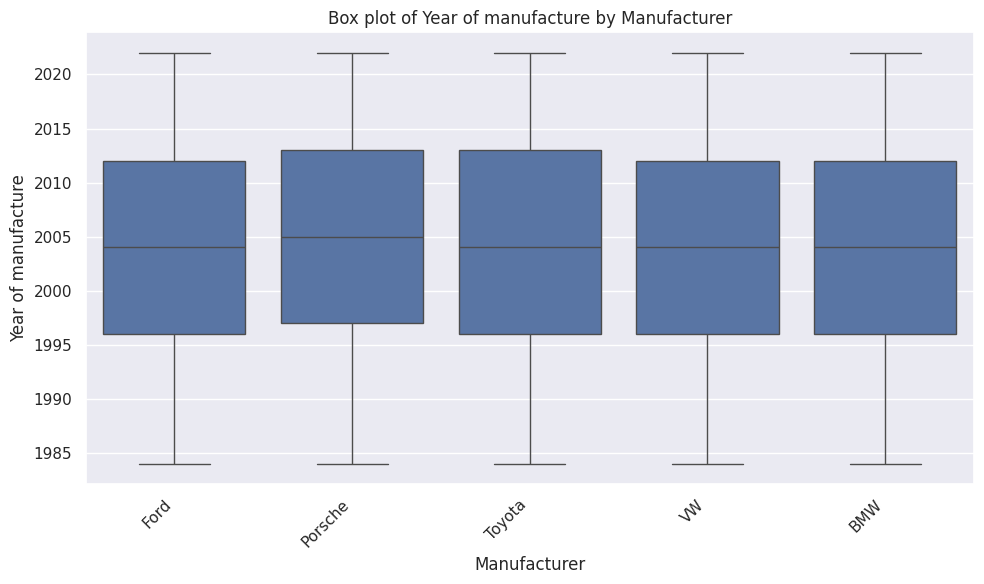

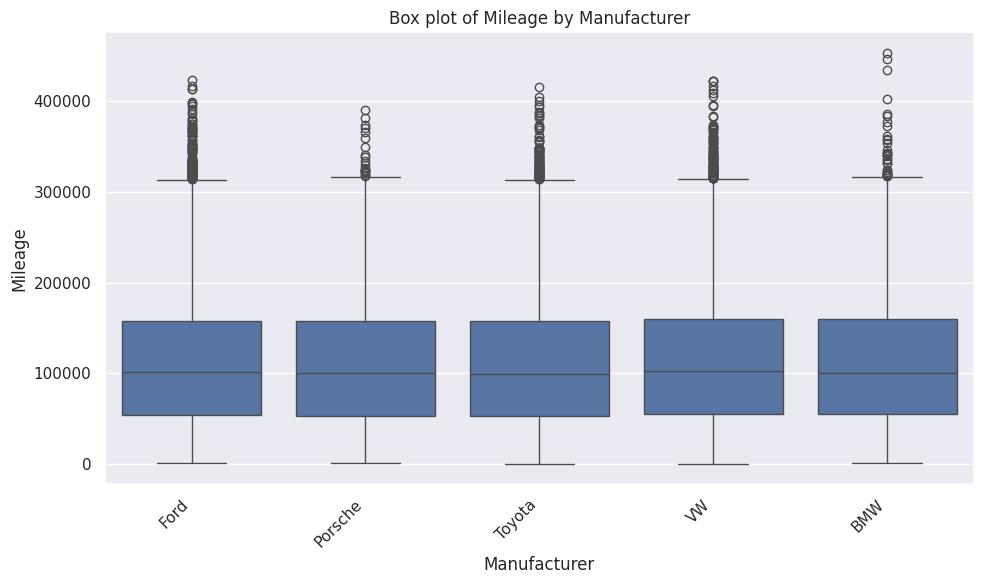

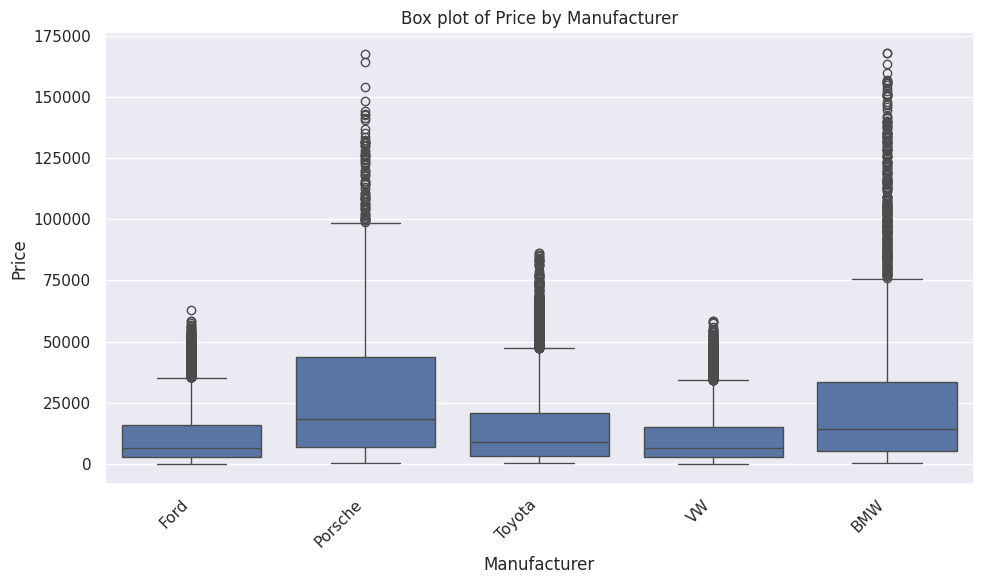

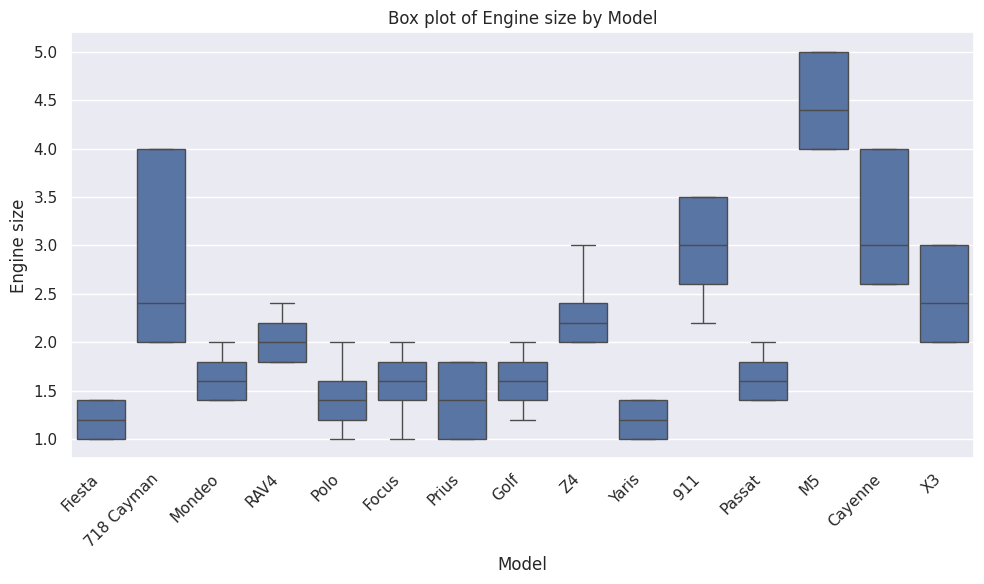

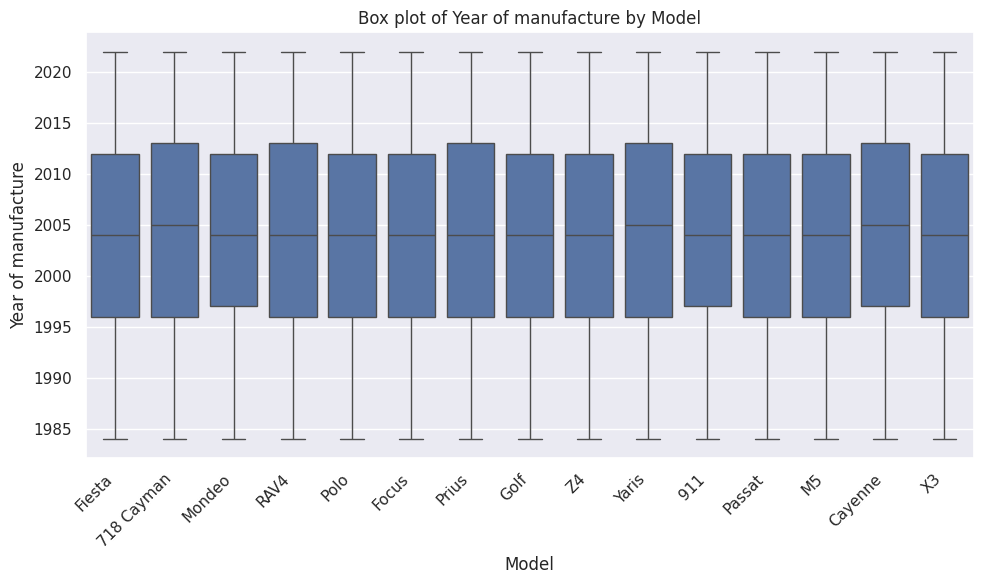

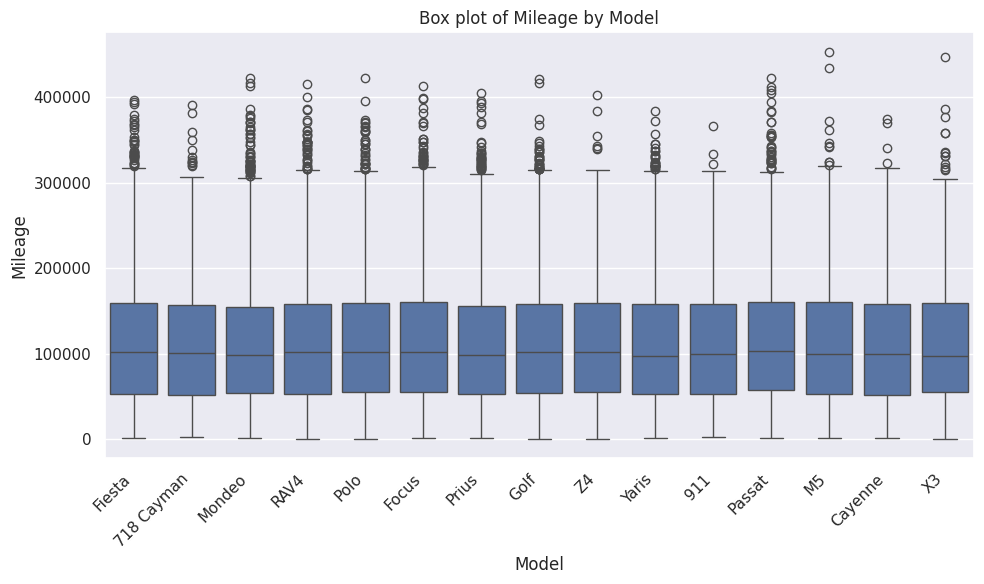

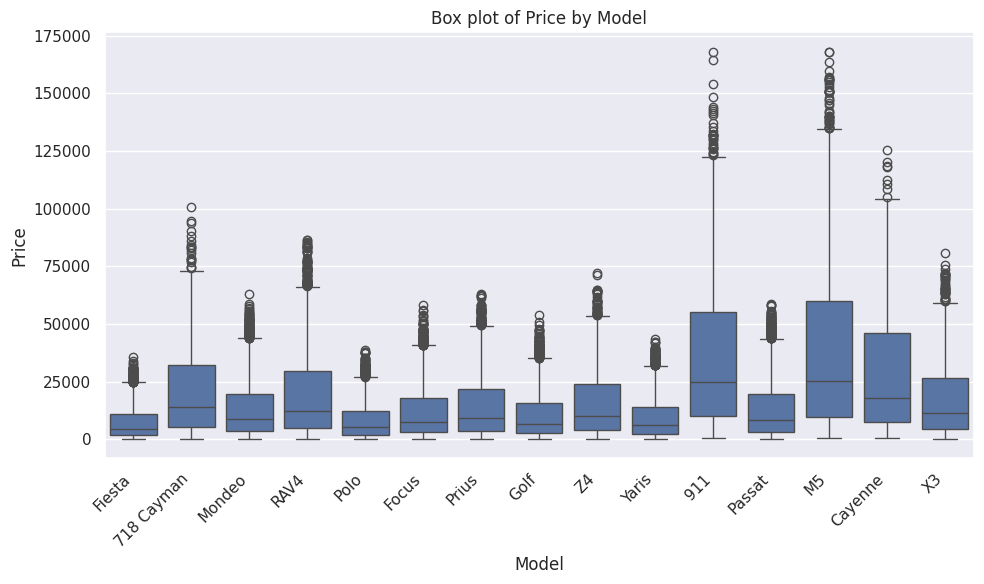

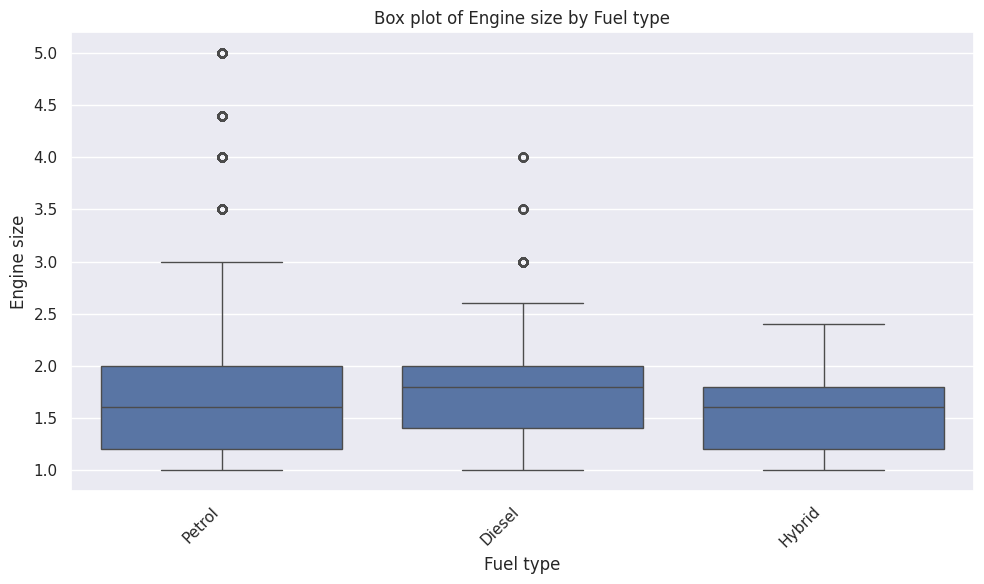

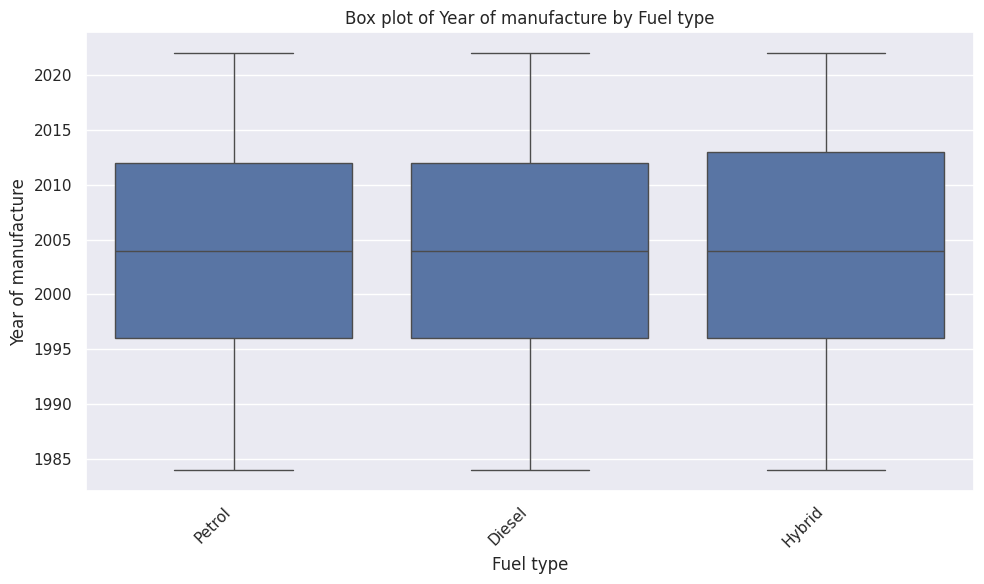

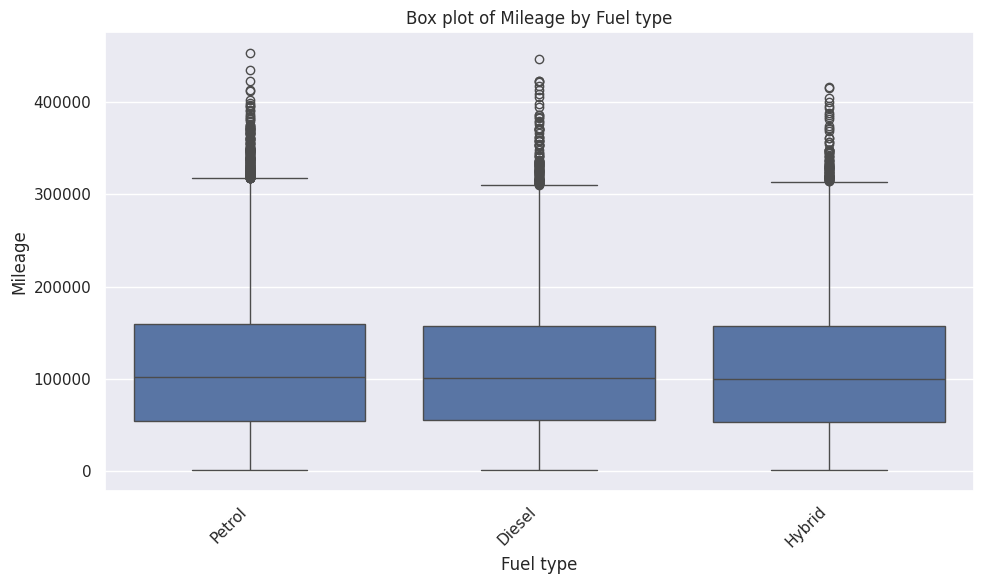

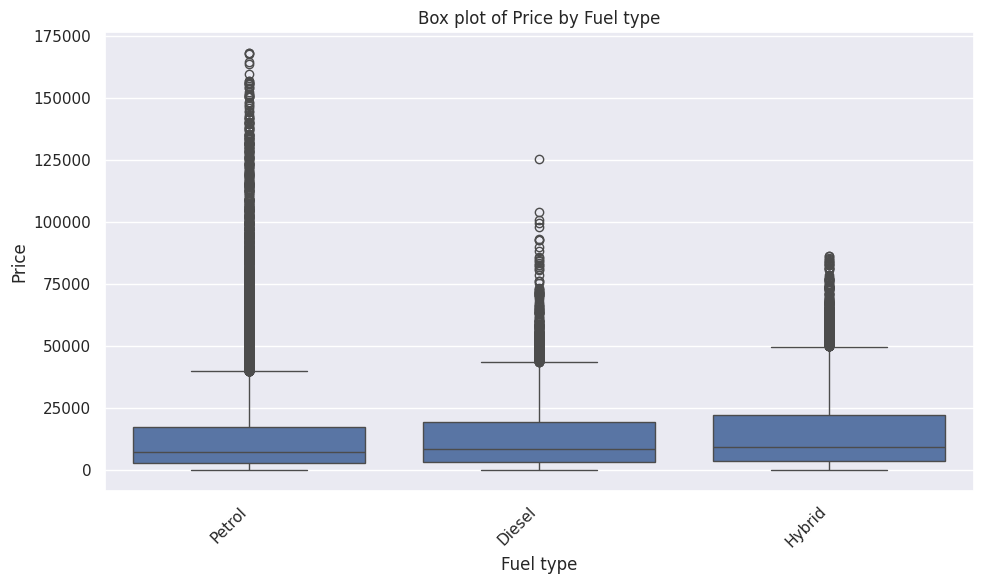

In [19]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

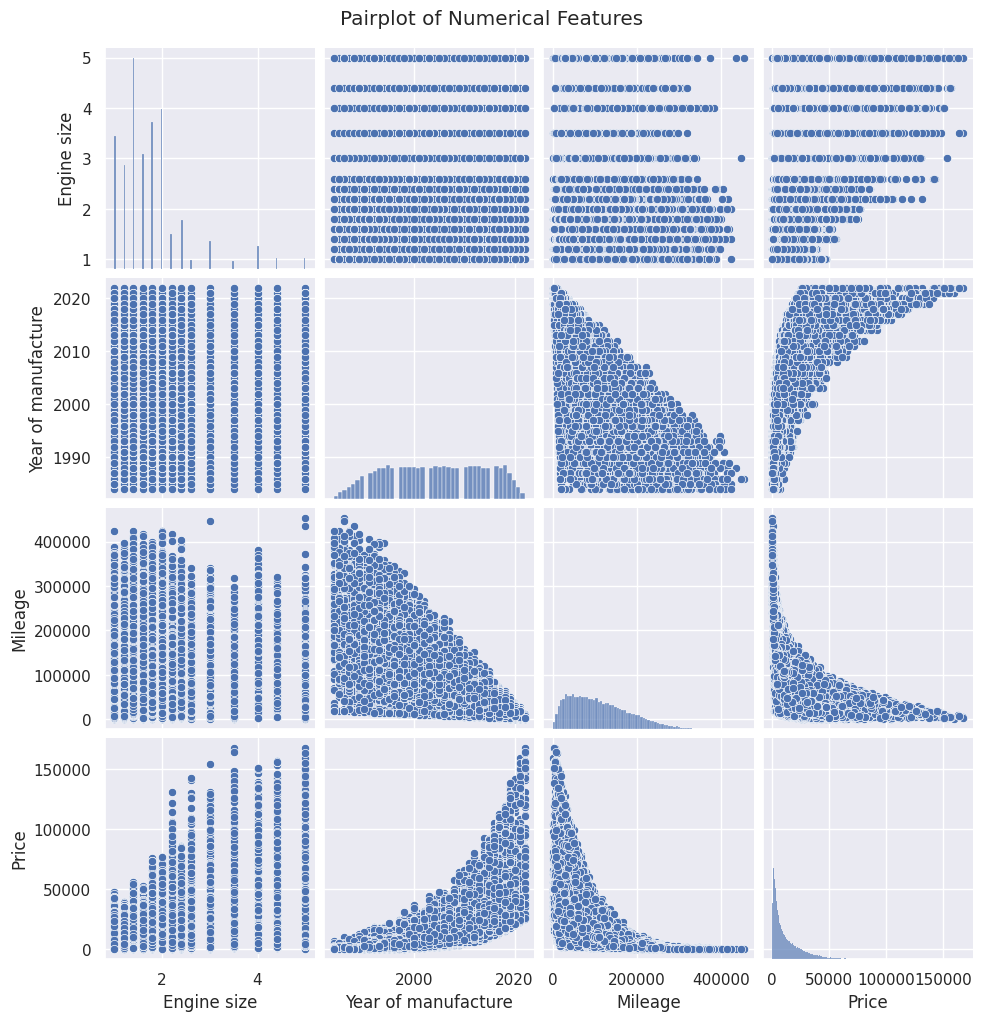

In [20]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

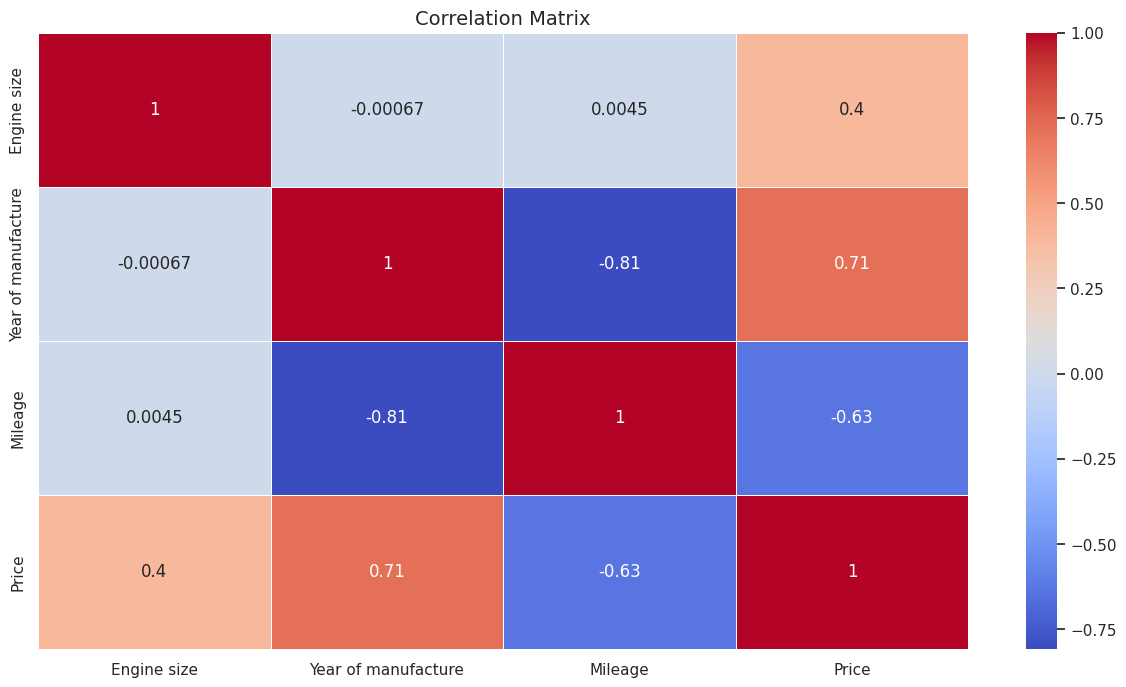

In [21]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you